# EEG Fast Fourier TransformationS (FFTS)



|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[5.frame_alignment.ipynb](./5.frame_alignment.ipynb)|<i>6.eeg_ffts.ipynb</i>|-|

In the previous notebook, [5.frame_alignment.ipynb](./5.frame_alignment.ipynb), we corrected the EEG timing for simulations and actually created a mapper dataframe to map frames to milliseconds per participant. In this notebook, we'll actually attempt to analyze EEG data by transforming the data into Power Spectral Density (PSD) charts.

## Step 0: Imports

In [37]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
from IPython.display import display, Markdown
import importlib

from scipy.signal import spectrogram, get_window
import plotly.subplots as sp
import plotly.graph_objects as go
import plotly.express as px

#from scipy.signal.windows import hamming

_CHANNELS = ['AF7', 'AF8', 'TP9', 'TP10']
_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (9, 13),
    "beta": (13, 30),
    "gamma": (30, 200)
}
_CHANNEL_COLORS = {
    'AF7':'blue',
    'AF8':"purple",
    'TP9':'red',
    'TP10':'orange'
}
_BAND_COLORS = {
    'delta': 'red',
    'theta': 'purple',
    'alpha': 'blue',
    'beta': 'green',
    'gamma': 'orange'
}

## Step 1: Calculating PSDs

For each EEG channel (AF7, AF8, TP9, and TP10), we can convert the time-series EEG signal data into a Power Spectral Density (PSD) form. The PSD informs us of which frequencies are strongest in the signal at a given timestamp.

In a typical scenario, we would use a Fast Fourier Transformation (FFT). However, I want to replicate the operations used by the Muse system to calculate the PSD. Let's create a helper function to do this, which uses `scipy.signal.spectrogram` to calculate the PSD. We also want to be cognizant of other parameters:

- `sample_rate` (default: 220)
- `window_size` (default: 256)
- `slide_rate` (default: 22)

### 1a. Computing PSDs

In [39]:
def compute_muse_psd(df, channels, sample_rate=220, window_size=256, slide_rate=22):
    
    # Get the hamming window class with the defined window size
    win = get_window('hamming', window_size)

    # Intiialize outputes
    psd = {}
    freqs = None
    times = None
    
    # For each channel, we:
    for ch in channels:
        # use `spectrogram` helper to calculate properties of the raw EEG signal in that channel
        f, t, Sxx = spectrogram(
            df[ch].values,
            fs=sample_rate,
            window=win,
            nperseg=window_size,
            noverlap=window_size - slide_rate,
            scaling='density',
            mode='psd'
        )
        # Convert to decibels (dB)
        Sxx_dB = 10 * np.log10(Sxx + 1e-12)
        
        # Add our responses to out outputs. We only do this once.
        psd[ch] = Sxx_dB
        if freqs is None:
            freqs = f
            times = t
    
    # Return the three data extracted from all eeg channels
    return freqs, times, psd

### 1b. Rendering the PSDs

In [40]:
def plot_muse_psd(
    psds, channels,
    title=True,
    cmap='viridis',
    zmin=-40, zmax=20,
    width=3000, height=500,
    dpi=100,
    savename=None,
    show_plot:bool=True
):
    # How many channels do we have?
    n_rows = len(psds)
    n_cols = len(channels)

    # Define the subplot grid
    fig, axes = plt.subplots( n_rows, n_cols, figsize=(width/dpi, height/dpi), dpi=dpi, constrained_layout=True)

    # Make the axis iterable
    if n_rows == 1 and n_cols == 1: axes = np.array([[axes]])
    elif n_rows == 1:               axes = np.array([axes])
    elif n_cols == 1:               axes = np.array([[ax] for ax in axes])

    # Start plotting
    for row_index in range(len(psds)):
        pre_title = f"{psds[row_index]['pre_title']} " if 'pre_title' in psds[row_index] else ""
        freqs = psds[row_index]['freqs']
        times = psds[row_index]['times']
        psd = psds[row_index]['psd']

        for col_index, ch in enumerate(channels):
            ax = axes[row_index][col_index]
            data = psd[ch]

            im = ax.imshow(
                data,
                aspect='auto',
                origin='lower',
                extent=[times[0], times[-1], freqs[0], freqs[-1]],
                cmap=cmap,
                vmin=zmin, vmax=zmax
            )
            ax.set_title(f"{pre_title} Channel = {ch}")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Freq (Hz)")

        # Hide any extra subplots
        #for j in range(col_index+1, len(axes_flat)):
        #    axes_flat[j].set_visible(False)

    # Add colorbar
    cbar = fig.colorbar(im, shrink=0.95)
    cbar.set_label("Power (dB)")

    # Add global title
    if title is not None: 
        if isinstance(title, bool): title = "Muse EEG Power Spectral Density (PSD)" 
        fig.suptitle(title, fontsize=14)

    # Save or show
    if savename is not None:    plt.savefig(savename, bbox_inches="tight")
    if show_plot:   plt.show()
    else:           plt.clf()

### 1c. Checking `P4_Muse2`

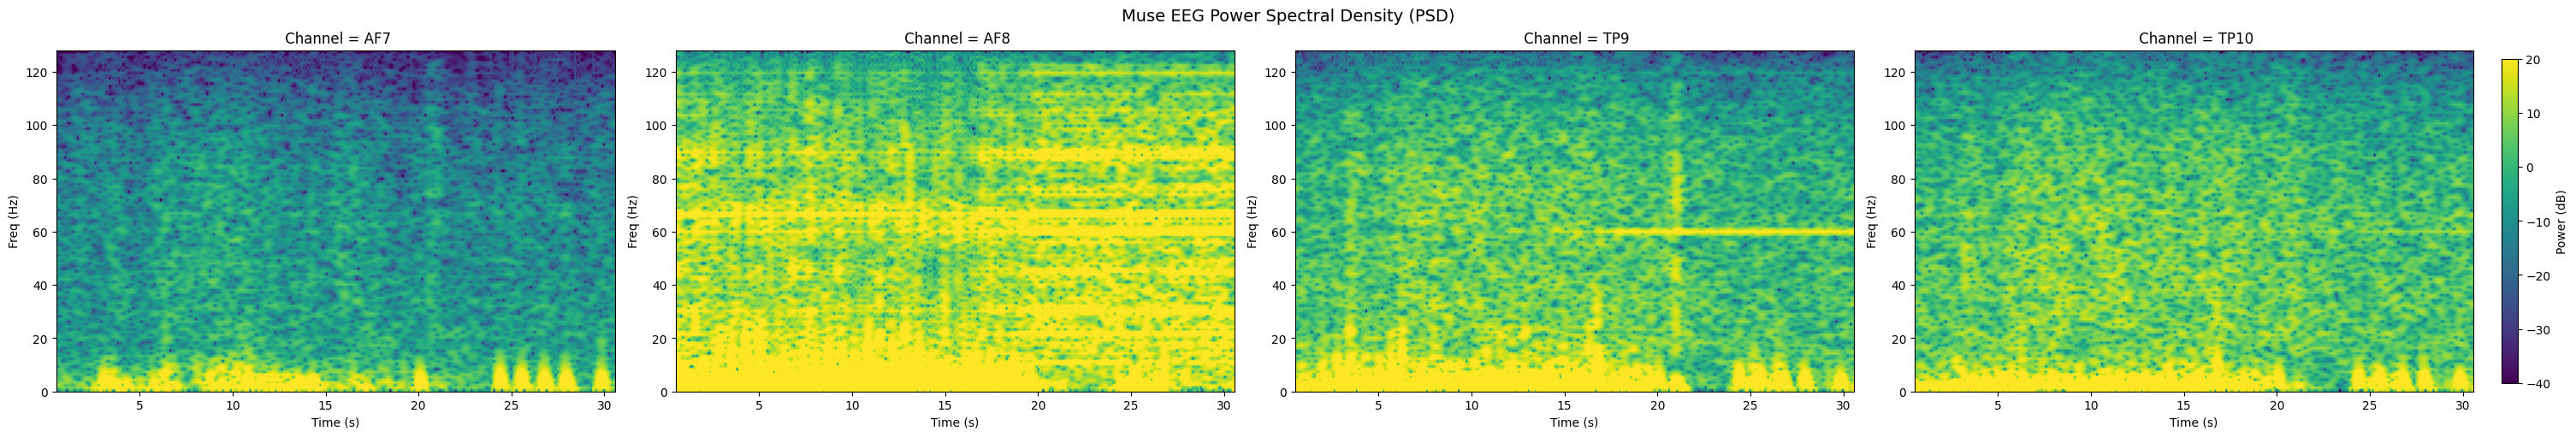

In [41]:
# Define some primitives
_DATA_DIR = os.path.join('.','data2')
_EXAMPLE_PARTICIPANT = 'P4_Muse2'
_EXAMPLE_TRIAL = 1

# Read trial data
tdir = os.path.join(_DATA_DIR, _EXAMPLE_PARTICIPANT, f"{_EXAMPLE_TRIAL}", "simulation")
raw_eeg = pd.read_csv(os.path.join(tdir, 'cor_eeg_raw_framed.csv'))

# Calculate the PSD from `compute_muse_psd`
freqs, times, psd = compute_muse_psd(raw_eeg, _CHANNELS, sample_rate=256)

# Plot
plot_muse_psd([{'freqs':freqs, 'times':times, 'psd':psd}], _CHANNELS)


## Step 2: Filtering EEG Further

Right now... something is wrong. This data is effectively useless. It appears that we may need an additional step: smoothing the EEG signal prior. That might hopefully help us identify cleaner PSDs.

In [3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb), we smoothed the data using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [42]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

sample_x = raw_eeg['total_time_ms'].to_list()
sample_data = [
    {'channel':'AF7', 'values':raw_eeg['AF7'].to_list(), 'color':'red'},
    {'channel':'AF8', 'values':raw_eeg['AF8'].to_list(), 'color':'orange'},
    {'channel':'TP9', 'values':raw_eeg['TP9'].to_list(), 'color':'blue'},
    {'channel':'TP10', 'values':raw_eeg['TP10'].to_list(), 'color':'purple'}
]

# since we already provided `generate_figure()` above, we just need to make sure that we create a helper function to connect `interact()` with `generate_figure()`
def update_plot(wl=150, poly=3, mode='nearest'):

    # Generate the savgol filter itself
    savgol = lambda d: savgol_filter(d, window_length=wl, polyorder=poly, mode=mode)

    # Plot a figure to showcase the TP9s of these two samples
    fig, axes = plt.subplots(2,2,figsize=(15,7.5))

    # Iterate through our two samples
    for i in range(len(sample_data)):
        sample = sample_data[i]
        channel = sample['channel']
        color = sample['color']
        sample_y = sample['values']

        # Smooth
        sample_ys = savgol(sample_y)

        # indices for plot
        col_index = math.floor(i % 2)
        row_index = math.floor(i/2)

        axes[row_index][col_index].plot(sample_x, sample_y, c=color, alpha=0.25)
        axes[row_index][col_index].plot(sample_x, sample_ys, c=color, alpha=1.0)
        axes[row_index][col_index].set_title(f"{channel}")


    # Render the plot
    plt.tight_layout()
    plt.show()


# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=150, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=3, min=1, max=5, step=1, description='Poly Order'),
    mode = Dropdown(options=['mirror', 'constant', 'nearest', 'wrap', 'interp'], value='nearest', description='Mode')
)

interactive(children=(FloatSlider(value=150.0, description='Window Length', max=200.0, min=10.0), IntSlider(va…

<function __main__.update_plot(wl=150, poly=3, mode='nearest')>

It might be optimal to smooth everything so that the `window_length = 150` and `polyorder=3`. Let's try running the PSD calculations with the smoothed data.

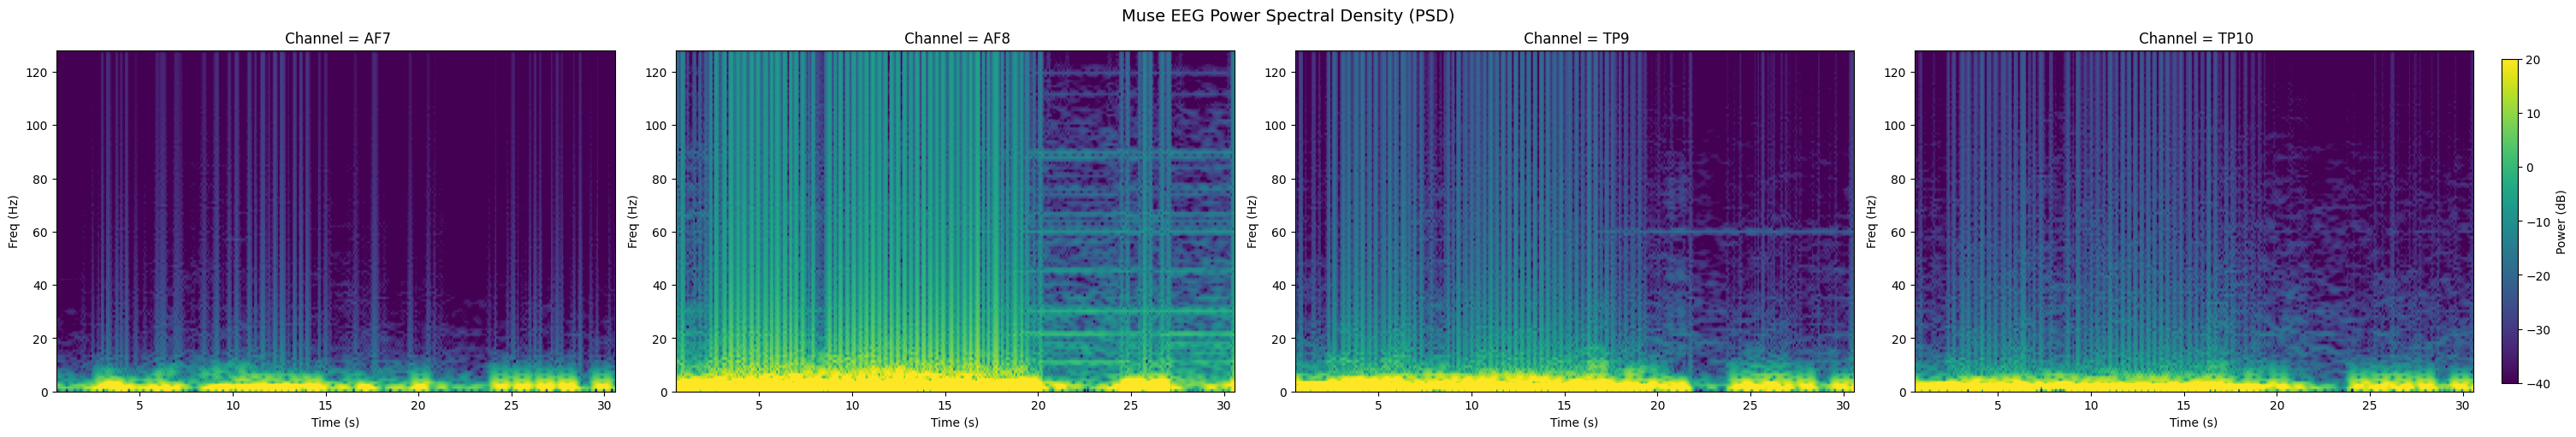

In [43]:
# Create a lambda function to reduce confusion
savgol = lambda x: savgol_filter(x, window_length=150, polyorder=3, mode='nearest')

# Re-import the data
smooth_eeg = pd.read_csv(os.path.join(tdir, 'cor_eeg_raw_framed.csv'))
for channel in _CHANNELS:
    v = smooth_eeg[channel]
    vs = savgol(v)
    smooth_eeg[channel] = vs

# Calculate the PSD from `compute_muse_psd`
freqs, times, psd = compute_muse_psd(smooth_eeg, _CHANNELS, sample_rate=256)

# Plot
plot_muse_psd([{'freqs':freqs, 'times':times, 'psd':psd}], _CHANNELS)

So with the cleaned data, we can interpret some commonalities:

- AF8 is perhaps the noisiest data and actually produces the most confusing PSD. Let's ignore that.
- AF7 is the cleaner version and indicates some pretty strong frequency powers in very low frequency ranges.

This graph alone doesn't help us with distinguishing the absolute powers of the PSDs though. Let's try to generate a new figure for that.

## Step 3: Absolute Band Powers

### 3a. Our Own Raw Data

In [44]:
def compute_bandpowers_time_series(freqs, times, psd, bands):
    
    records = []
    for ch, Sxx_dB in psd.items():
        # Convert back from dB to linear scale
        Sxx_linear = 10 ** (Sxx_dB / 10)

        for band, (fmin, fmax) in bands.items():
            idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]

            if len(idx) == 0:
                continue

            # Sum across frequency bins, keep per-time-frame values
            band_power = np.sum(Sxx_linear[idx, :], axis=0)

            # Logarithm → absolute band power
            band_power_log = np.log10(band_power + 1e-12)

            for t, val in zip(times, band_power_log):
                records.append((t, ch, band, val))

    bandpowers = pd.DataFrame(records, columns=["time", "channel", "band", "power"])
    return bandpowers

In [45]:
def plot_time_series(
        df, 
        x_col, 
        y_col, 
        c_col, 
        facet_col=None, 
        facet_row=None, 
        color_dict      = None, 
        labels          = None, 
        title:str       = None, 
        width:float     = 3000, 
        height:float    = 500, 
        dpi:int         = 100,
        sharex          = False,
        sharey          = False,
        savename:str    = None,
        show_plot:bool  = True
):

    # Define axis labels
    x_label = labels[x_col] if labels is not None and x_col in labels else x_col
    y_label = labels[y_col] if labels is not None and y_col in labels else y_col

    # Determine facet structure
    facet_row_values = df[facet_row].unique() if facet_row else [None]
    facet_col_values = df[facet_col].unique() if facet_col else [None]
    nrows = len(facet_row_values)
    ncols = len(facet_col_values)

    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(width/dpi,height/dpi), dpi=dpi, sharex=sharex, sharey=sharey, constrained_layout=True)

    # Make axes iterable
    if nrows == 1 and ncols == 1:   axes = np.array([[axes]])
    elif nrows == 1:                axes = np.array([axes])
    elif ncols == 1:                axes = np.array([[ax] for ax in axes])

    # Plotting
    for i, r_val in enumerate(facet_row_values):
        for j, c_val in enumerate(facet_col_values):
            
            # Create a reference to the current axis
            ax = axes[i, j]

            # Get a subset of your DF
            subset = df.copy()
            if facet_row:   subset = subset[subset[facet_row] == r_val]
            if facet_col:   subset = subset[subset[facet_col] == c_val]

            # Plot the groups based on color
            for group, gdf in subset.groupby(c_col):
                color = color_dict[group] if color_dict and group in color_dict else None
                ax.plot(gdf[x_col], gdf[y_col], label=str(group), color=color)
            
            # Facet Titles
            title_parts = []
            if facet_row: title_parts.append(f"{facet_row} = {r_val}")
            if facet_col: title_parts.append(f"{facet_col} = {c_val}")
            ax.set_title(", ".join(title_parts))
            if i == nrows - 1:  ax.set_xlabel(x_label)
            if j == 0:          ax.set_ylabel(y_label)

            # Legend
            if i == 0 and j == 0:   ax.legend()
    
    # Global plot qualities
    if title is not None:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save if needed
    if savename is not None:    plt.savefig(savename, bbox_inches='tight')
    if show_plot:               plt.show()
    else:                       plt.clf()

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


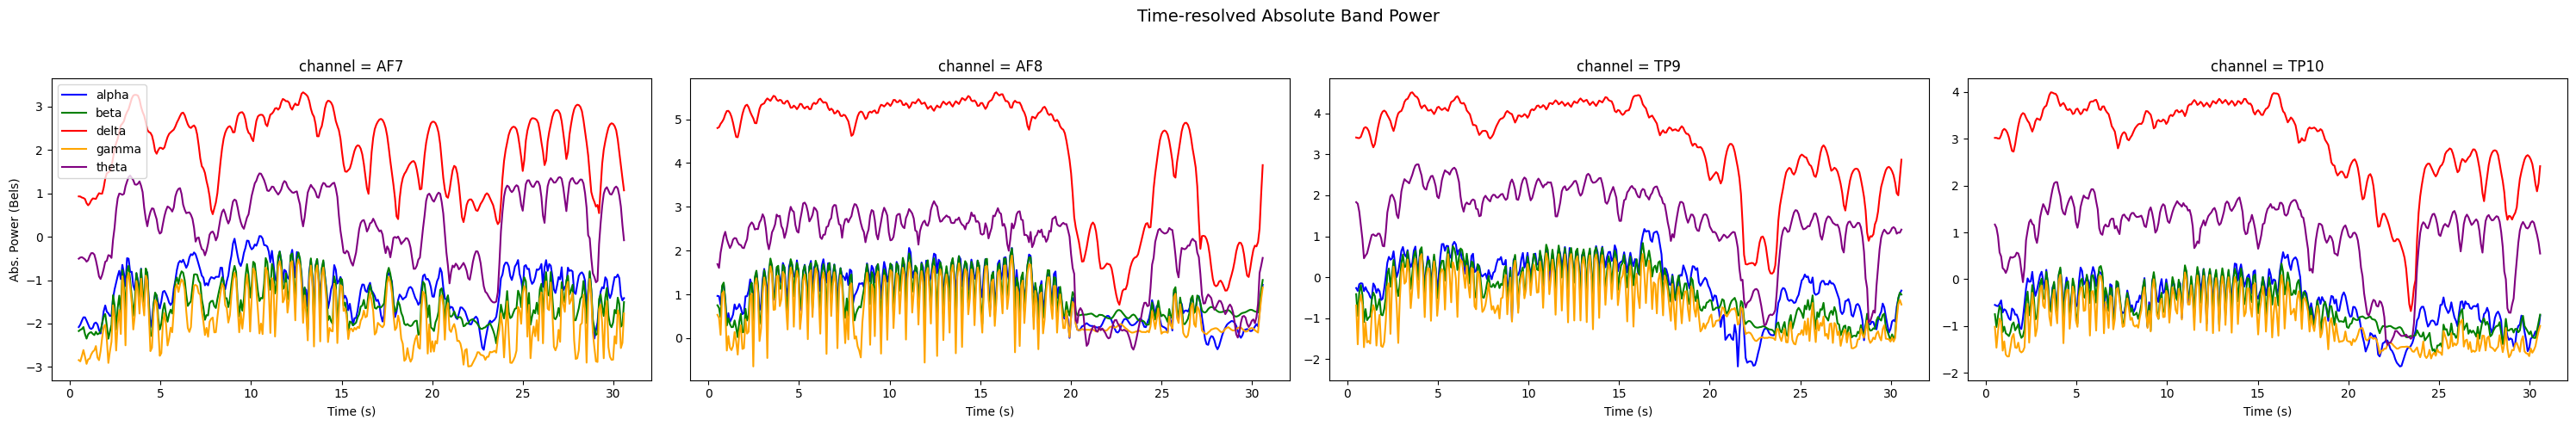

In [46]:
# Compute absolute band powers
bandpowers = compute_bandpowers_time_series(freqs, times, psd, _BANDS)

# Plot the absolute band powers"
plot_time_series(bandpowers, x_col='time', y_col='power', c_col='band', facet_col='channel', color_dict=_BAND_COLORS, labels={"power": "Abs. Power (Bels)", "time": "Time (s)"}, title="Time-resolved Absolute Band Power")

### 3b. Comparison with Muse's Powers

Muse provides its own estimations of the Absolute Power PSDs. Let's visualize that too.

In [47]:
# Import the necessary helper
from components import eeg_handling
importlib.reload(eeg_handling)

<module 'components.eeg_handling' from 'd:\\Projects\\eeg_blink_calibration\\src\\components\\eeg_handling.py'>

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


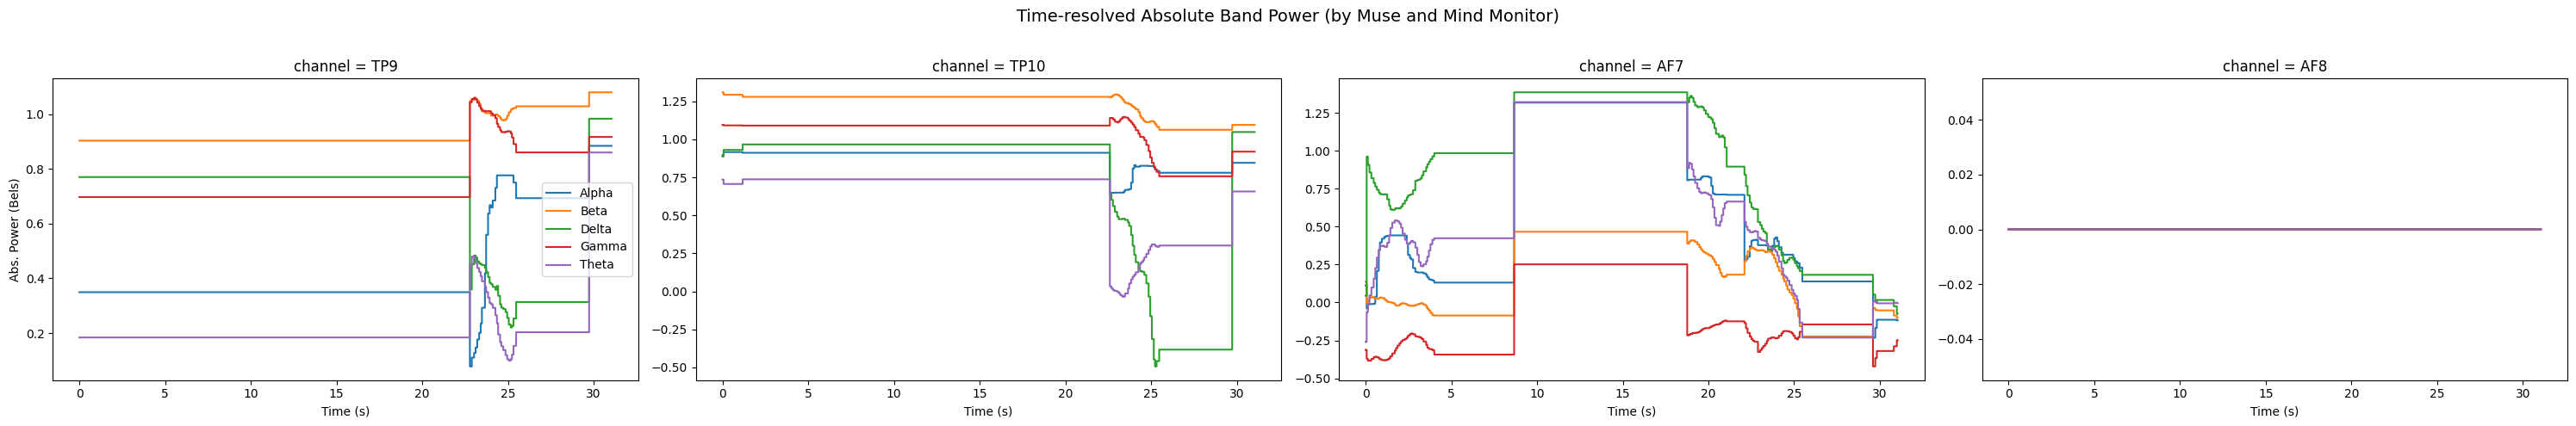

In [48]:
# Read the processed EEG
processed_eeg = pd.read_csv(os.path.join(tdir, 'cor_eeg_pro_framed.csv'))

# Need to melt the processed EEG to fit a format usable for the chart above
pro_eeg = eeg_handling.melt_processed_eeg(processed_eeg, timestamp_cols=['total_time_ms'])
pro_eeg['time'] = pro_eeg['total_time_ms'] / 1000

# Plot
plot_time_series(pro_eeg, x_col='time', y_col='power', c_col='band', facet_col='channel', color_dict=_BAND_COLORS, labels={"power": "Abs. Power (Bels)", "time": "Time (s)"}, title="Time-resolved Absolute Band Power (by Muse and Mind Monitor)", width=3000, height=500, dpi=100)

Well... I guess `P4_Muse2` kind of fails if we look at the processed EEG data only. But the raw data gives some better ideas of how this works.

## Exploration: Blinks

What happens if we look at the blinked data?

In [49]:
cdir = os.path.join(_DATA_DIR, _EXAMPLE_PARTICIPANT, f"{_EXAMPLE_TRIAL}", "calibration")
cal_eeg = pd.read_csv(os.path.join(cdir, 'eeg_raw.csv'))
cdf = pd.read_csv(os.path.join(cdir, 'blink_ranges.csv'))

# Re-import the data
for channel in _CHANNELS:
    v = cal_eeg[channel]
    vs = savgol(v)
    cal_eeg[channel] = vs

start_ms = cal_eeg['unix_ms'].iloc[0] + 5000
end_ms = cal_eeg['unix_ms'].iloc[-1] + 500
cal_eeg = cal_eeg[cal_eeg['unix_ms'].between(start_ms, end_ms)]

display(cal_eeg)
display(cdf)

,unix_sec,unix_ms,rel_sec,rel_ms,TP9,TP10,AF7,AF8
1284,1.759611e+09,1759611089660,25.703,25703,840.855436,835.005364,762.305948,806.870490
1285,1.759611e+09,1759611089660,25.703,25703,841.478502,836.047485,761.209740,806.294488
1286,1.759611e+09,1759611089660,25.703,25703,842.463306,837.611483,760.253955,806.824118
1287,1.759611e+09,1759611089660,25.703,25703,843.472832,838.965394,759.468935,806.304759
1288,1.759611e+09,1759611089660,25.703,25703,844.179488,839.453920,758.673819,806.927697
...,...,...,...,...,...,...,...,...
2947,1.759611e+09,1759611096142,32.185,32185,809.957749,793.870311,786.443494,852.252571
2948,1.759611e+09,1759611096142,32.185,32185,810.358637,793.602772,786.540347,854.073779
2949,1.759611e+09,1759611096143,32.186,32186,810.816259,792.919097,786.686200,856.180282
2950,1.759611e+09,1759611096143,32.186,32186,811.216965,792.462682,786.813454,856.842337


,overlap_counter,overlap_unix_ms,blink_unix_ms,start_unix_ms,end_unix_ms,duration
0,1,1759611090491,1759611090920,1759611090391,1759611091020,629
1,2,1759611091741,1759611092147,1759611091641,1759611092247,606
2,3,1759611092964,1759611093343,1759611092864,1759611093443,579
3,4,1759611094173,1759611094381,1759611094073,1759611094481,408


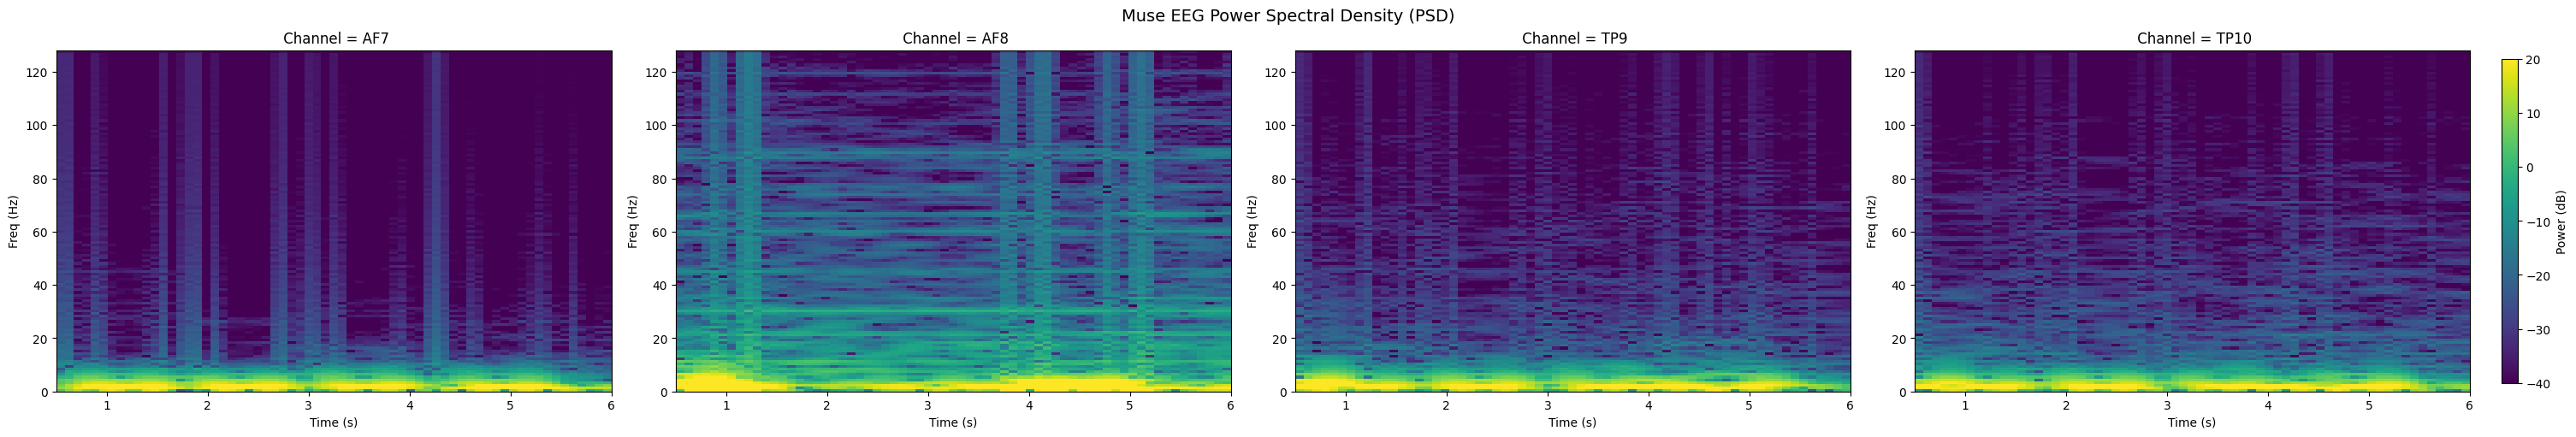

In [50]:
# Calculate the PSD from `compute_muse_psd`
cfreqs, ctimes, cpsd = compute_muse_psd(cal_eeg, _CHANNELS, sample_rate=256)

# Plot
plot_muse_psd([{'p':'Blinks', 'freqs':cfreqs, 'times':ctimes, 'psd':cpsd}], _CHANNELS)

C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


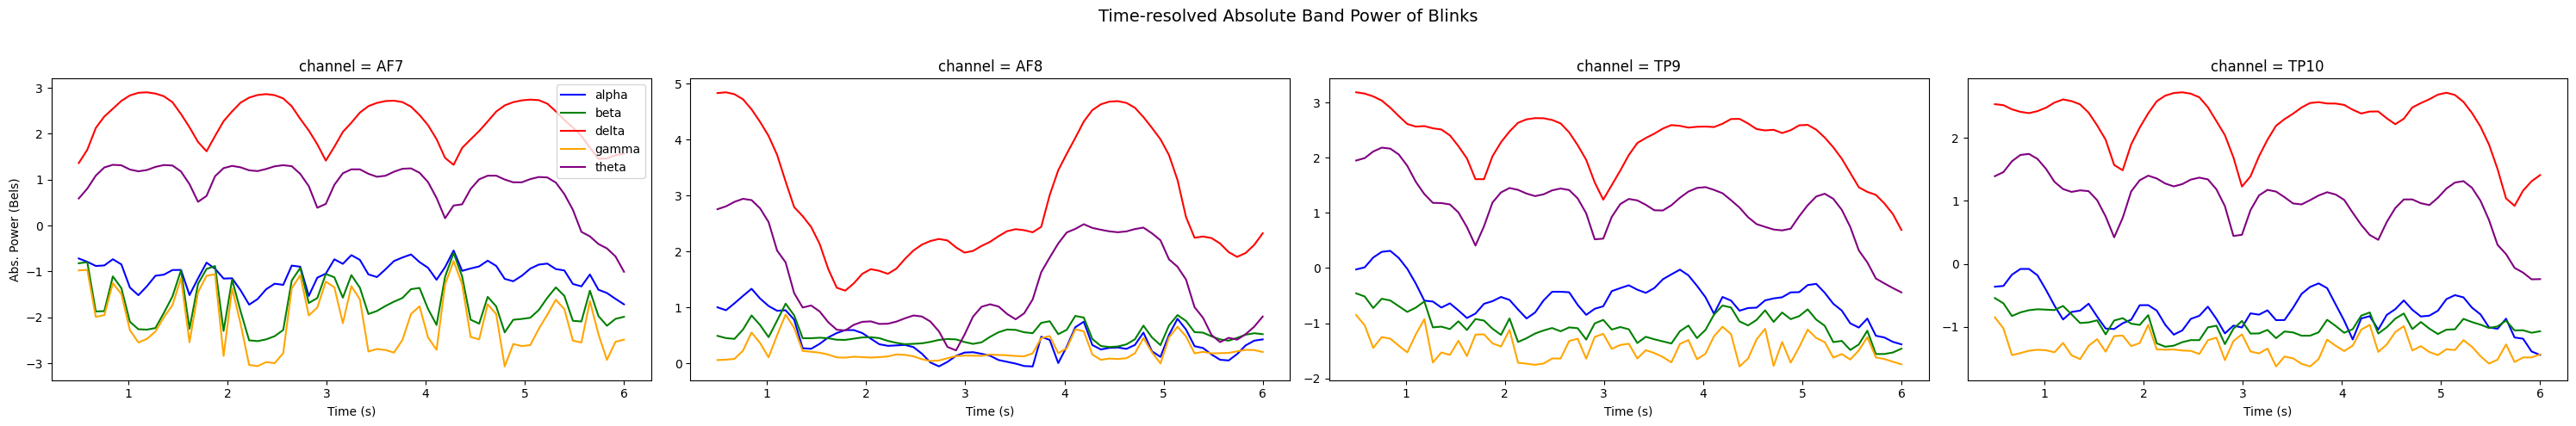

In [51]:
# Compute absolute band powers
cbandpowers = compute_bandpowers_time_series(cfreqs, ctimes, cpsd, _BANDS)

# Plot the absolute band powers
plot_time_series(cbandpowers, x_col='time', y_col='power', c_col='band', facet_col='channel', color_dict=_BAND_COLORS, labels={"power": "Abs. Power (Bels)", "time": "Time (s)"}, title="Time-resolved Absolute Band Power of Blinks", width=3000, height=500, dpi=100)

Okay, so I don't think this is really going to get us anywhere... The data is simply too noisy...

## Step 4: Processing All Participants

Let's process the data for each participant, for each trial. Let's do the following:

- `freqs`, `times`, and `psd` are saved in a single JSON file for access later.
- `bandpowers` is saved as a CSV dataframe.
- Both files will be saved in an `outputs` directory inside of `simulation`.

In [52]:
import json

def save_psds(freqs, times, psd:pd.DataFrame, savedir:str):
    # Save 2 files: a JSON containing freqs, and a Dataframe containing PSDs
    freqs_serializable = freqs.tolist()
    times_serializable = times.tolist()
    psd_serializable = {k: v.tolist() for k, v in psd.items()}
    data = { 'freqs':freqs_serializable, 'times':times_serializable, 'psd':psd_serializable }
    with open(os.path.join(savedir, "psd_details.json"), "w") as f:
        json.dump(data, f, indent=2)

In [53]:
from components import file_handling
importlib.reload(file_handling)

# Define the savgol
savgol = lambda x: savgol_filter(x, window_length=150, polyorder=3, mode='nearest')

# Define the participants we want to look at
_ACTIVE_PARTICIPANTS = ['P1', 'PI2', 'P4_Muse2', 'P5', 'P6', 'P7', 'P9' ]

# Create an output directory for outputted directories
figure_dir = os.path.join('.', 'docs', '6.eeg_ffts')
file_handling.mkdirs(figure_dir)

# We iterate through each participant, through each trial
for p in _ACTIVE_PARTICIPANTS:

    # Generate the input directory in `data2`, and the output directory for figures
    pdir = os.path.join('.', 'data2', p)
    fdir = os.path.join(figure_dir, p)
    file_handling.mkdirs(fdir)

    # Read the trials 
    trials = pd.read_csv(os.path.join(pdir, 'trials.csv'))

    # Create a list to concatenate the smoothed EEGs, psds, and bandpowers
    smoothed_eegs_list = []
    psds_list = []
    bandpowers_list = []
    
    # Iterate through trials
    for _, trial in trials.iterrows():

        # Trial ID
        trial_id = trial['trial_id']
        trial_name = trial['trial_name']

        # Generate the input directory to the trial
        tdir = os.path.join(pdir, f"{trial_id}", 'simulation')

        # Generate the output directory for generated datasets
        odir = os.path.join(tdir, 'outputs')
        file_handling.mkdirs(odir)

        # Read the corrected raw EEG data, smooth it, and contribute it to `eegs`
        eeg = pd.read_csv(os.path.join(tdir, 'cor_eeg_raw_framed.csv'))
        eeg['trial_id'] = trial_id
        eeg['total_time_sec'] = eeg['total_time_ms'] / 1000
        for channel in _CHANNELS:   eeg[channel] = savgol(eeg[channel].to_list())
        melted_eeg = eeg_handling.melt_raw_eeg(eeg, timestamp_cols=['trial_id', 'unix_ms', 'cor_unix_ms', 'deltaTime_ms', 'rel_frame', 'total_time_ms', 'total_time_sec'])
        smoothed_eegs_list.append(melted_eeg)

        # Perform PSD calculations
        freqs, times, psd = compute_muse_psd(eeg, _CHANNELS, sample_rate=256)
        psds_list.append({'pre_title':f"Trial {trial_id}: {trial_name} | ", 'freqs':freqs, 'times':times, 'psd':psd})

        # Perform the bandpowers calculations
        bandpower = compute_bandpowers_time_series(freqs, times, psd, _BANDS)

        # Re-calculate a new column to measure the relative frame number. The `time` column is in seconds, and we need to convert between seconds and ms
        # The `frames_to_ms.csv` file should contain the proper way to map between milliseconds and frames
        frames_to_ms = pd.read_csv(os.path.join(tdir, 'frames_to_ms.csv'))
        total_frames = frames_to_ms['rel_frame'].iloc[-1]
        total_time = frames_to_ms['total_time_ms'].iloc[-1]
        frames_per_time = total_frames / total_time

        # To calculate relative frames, we need to convert from sec to milliseconds, and then multiply by frames_per_time ratio
        bandpower['time_ms'] = bandpower['time'] * 1000
        bandpower['rel_frame'] = bandpower['time_ms'] * frames_per_time 

        # Finally, add our trial's bandpowers to the greater bandpowers list
        bandpower['trial_id'] = trial_id
        bandpowers_list.append(bandpower)
        
        # Save the output 
        melted_eeg.to_csv(os.path.join(odir, 'eeg_smoothed.csv'), index=False)
        save_psds(freqs, times, psd, odir)
        bandpower.to_csv(os.path.join(odir, 'bandpowers.csv'), index=False)

    # Combined the smoothed EEGs, generate a plot, and save it
    smoothed_eegs = pd.concat(smoothed_eegs_list)
    bandpowers = pd.concat(bandpowers_list)
    plot_time_series(smoothed_eegs, x_col='total_time_sec', y_col='voltage', c_col='channel', facet_col='channel', facet_row='trial_id', color_dict=_CHANNEL_COLORS, labels={"voltage": "Voltage", "total_time_sec": "Time (s)"}, title="Smoothed Simulation EEG Signals", width=9000, height=6000, dpi=300, savename=os.path.join(fdir, f"{p}_Smoothed_EEG.png"), show_plot=False)
    plot_muse_psd(psds_list, _CHANNELS, title=f"Participant {p}'s Power Spectral Densities per Trial", height=500*6, savename=os.path.join(fdir, f"{p}_PSD_Heatmaps.png"), show_plot=False)
    plot_time_series(bandpowers, x_col='time', y_col='power', c_col='band', facet_col='channel', facet_row='trial_id', color_dict=_BAND_COLORS, labels={"power": "Abs. Power (Bels)", "time": "Time (s)"}, title=f"{p}: Time-resolved Absolute Band Power", width=9000, height=1000*6, dpi=300, savename=os.path.join(fdir, f"{p}_Abs_Band_Powers.png"), show_plot=False)


C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Kim\AppData\Local\Temp\ipykernel_15432\4132977081.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Ryan Ki

<Figure size 9000x6000 with 0 Axes>

<Figure size 3000x3000 with 0 Axes>

<Figure size 9000x6000 with 0 Axes>

<Figure size 9000x6000 with 0 Axes>

...

<Figure size 3000x3000 with 0 Axes>

<Figure size 9000x6000 with 0 Axes>

<Figure size 9000x6000 with 0 Axes>

<Figure size 3000x3000 with 0 Axes>

<Figure size 9000x6000 with 0 Axes>

--- 

## Appendix

In [54]:
def plot_time_series_plotly(df, x_col, y_col, c_col, facet_col=None, facet_col_wrap=None, facet_row=None, facet_col_spacing = 0.025, facet_row_spacing = 0.15, color_dict=None, labels=None, title=None, width=2000, height=800, separate_plot_scales=False, savename=None):
    if labels is not None:
        assert x_col in labels, "X-Column feature doesn't have a label"
        assert y_col in labels, "Y-Column feature doesn't have a label"
    fig = px.line(
        df,
        width=width,
        height=height,
        x=x_col, y=y_col,
        color=c_col,
        color_discrete_map=color_dict,
        facet_col=facet_col, facet_col_wrap=facet_col_wrap,
        facet_row=facet_row,
        facet_col_spacing = facet_col_spacing,
        facet_row_spacing = facet_row_spacing,
        labels=labels,
        title=title
    )
    if separate_plot_scales: fig.update_yaxes(matches=None)  # allow each subplot its own scale

    if savename is not None:
        fig.write_image(savename, engine='orca')
    fig.show()

In [55]:
def plot_muse_psd_plotly(freqs, times, psd, channels, savename=None):

    # Generate the figure
    fig = sp.make_subplots(rows=2, cols=2, subplot_titles=channels)

    # Iterate through the channels provided
    for i, ch in enumerate(channels):

        # We'll produce a heatmap to visualize the x-axis as time, the y-axis as the frequency range, and the color/hue representing the "power" of the frequency
        heatmap = go.Heatmap(
            z=psd[ch],
            x=times,
            y=freqs,
            colorscale='Viridis',
            colorbar=dict(title='Power (dB)'),
            zmin=-40, zmax=20
        )
        row, col = divmod(i, 2)
        fig.add_trace(heatmap, row=row+1, col=col+1)
        fig.update_yaxes(title_text="Freq (Hz)", row=row+1, col=col+1)
        fig.update_xaxes(title_text="Time (s)", row=row+1, col=col+1)

    # Minor layout updates
    fig.update_layout(
        title="Muse EEG Power Spectral Density (PSD)",
        height=900,
        width=1000
    )

    if savename is not None:
        fig.write_image(savename)
    fig.show()